In [14]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score
)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('Imports OK')

Device: cuda
Imports OK


In [ ]:
# ── Data Loading ──────────────────────────────────────────────────────────────
df_mal = pd.read_csv('krono_malware_clean.csv')
df_ben = pd.read_csv('krono_benign_clean.csv', engine='python')
df = pd.concat([df_mal, df_ben], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'KronoDroid — Malware: {len(df_mal):6d}  Benign: {len(df_ben):6d}  Toplam: {len(df):6d}')
print(f'Sütun: {df.shape[1]}')

y_all = (df['label'] == 'malware').astype(int).values
print(f'Malware oranı: {y_all.mean():.3f}')

# AndroZoo — temporal test set (2025-2026, out-of-distribution)
df_az_mal = pd.read_csv('androzoo/androzoo_malware.csv')
df_az_ben = pd.read_csv('androzoo/androzoo_benign.csv', engine='python')
df_androzoo = pd.concat([df_az_mal, df_az_ben], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
y_androzoo = (df_androzoo['label'] == 'malware').astype(int).values
print(f'\nAndroZoo  — Malware: {len(df_az_mal):6d}  Benign: {len(df_az_ben):6d}  Toplam: {len(df_androzoo):6d}')
print(f'Malware oranı: {y_androzoo.mean():.3f}')

In [16]:
# ── Feature Analizi ───────────────────────────────────────────────────────────
#
# Sorunlu feature kategorileri:
#   1. Tamamen -1 olan sütunlar (sentinel, bilgi taşımıyor) → DROP
#   2. Kısmi -1 sentinel sütunlar  ("olay gerçekleşmedi") → flag + 0 ile doldur
#   3. Ters korelasyonlu feature'lar  (yüksek = benign) → ×(-1) ile çevir
#   4. Yüksek çarpıklık (skew > 5)    → log1p dönüşümü

META_COLS = ['package_name', 'label', 'timestamp']
feat_df   = df.drop(columns=META_COLS)
feat_cols = list(feat_df.columns)

# 1. Tamamen sentinel sütunlar (>%99 -1)
sentinel_pct  = {c: (feat_df[c] == -1).mean() for c in feat_cols}
DROP_SENTINEL = [c for c, p in sentinel_pct.items() if p > 0.99]
print(f'[DROP] 100% sentinel sütunlar: {len(DROP_SENTINEL)}')
for c in DROP_SENTINEL:
    print(f'  {c}')

# 2. Kısmi sentinel sütunlar
PARTIAL_SENTINEL = [c for c, p in sentinel_pct.items() if 0.01 < p <= 0.99]
print(f'\n[FLAG+IMPUTE] Kısmi sentinel sütunlar: {len(PARTIAL_SENTINEL)}')
for c in PARTIAL_SENTINEL:
    pct = sentinel_pct[c]
    print(f'  {c}: %{100*pct:.1f}')

# 3. Ters korelasyonlu feature'lar  (corr < -0.05)
y_s  = pd.Series(y_all)
corrs = feat_df.corrwith(y_s).dropna()
REVERSE_FEATS = corrs[corrs < -0.05].sort_values()
print(f'\n[REVERSE] Ters korelasyonlu (< -0.05) feature\'lar: {len(REVERSE_FEATS)}')
for c, v in REVERSE_FEATS.items():
    print(f'  {c}: r={v:.4f}  → ×(-1) ile çeviriliyor')

# 4. Yüksek çarpıklık (zaten log-dönüşümlü olmayanlar)
active_cols  = [c for c in feat_cols if c not in DROP_SENTINEL]
non_log_cols = [c for c in active_cols if not c.startswith('log1p_')]
skews        = feat_df[non_log_cols].skew().abs()
HIGH_SKEW    = skews[skews > 5].index.tolist()
print(f'\n[LOG1P] Yüksek çarpıklık (|skew|>5) → log1p dönüşümü: {len(HIGH_SKEW)} sütun')

[DROP] 100% sentinel sütunlar: 8
  first_sms_ms
  seq_first_reflect_exec_ms
  seq_first_dex_reflect_ms
  seq_first_file_network_ms
  seq_first_crypto_network_ms
  seq_first_anti_exec_ms
  seq_first_surveil_network_ms
  seq_first_clipboard_network_ms

[FLAG+IMPUTE] Kısmi sentinel sütunlar: 11
  first_network_ms: %53.2
  first_crypto_ms: %92.0
  first_anti_analysis_ms: %68.2
  first_file_write_ms: %66.3
  first_reflection_ms: %64.9
  first_exec_ms: %95.8
  first_dynamic_load_ms: %70.7
  delta_exec_after_reflection: %96.8
  delta_network_after_file: %73.5
  delta_network_after_crypto: %93.0
  delta_reflection_after_dex: %80.3

[REVERSE] Ters korelasyonlu (< -0.05) feature'lar: 3
  session_duration_ms: r=-0.4432  → ×(-1) ile çeviriliyor
  rapid_burst_flag: r=-0.2413  → ×(-1) ile çeviriliyor
  delta_network_after_crypto: r=-0.0552  → ×(-1) ile çeviriliyor

[LOG1P] Yüksek çarpıklık (|skew|>5) → log1p dönüşümü: 103 sütun


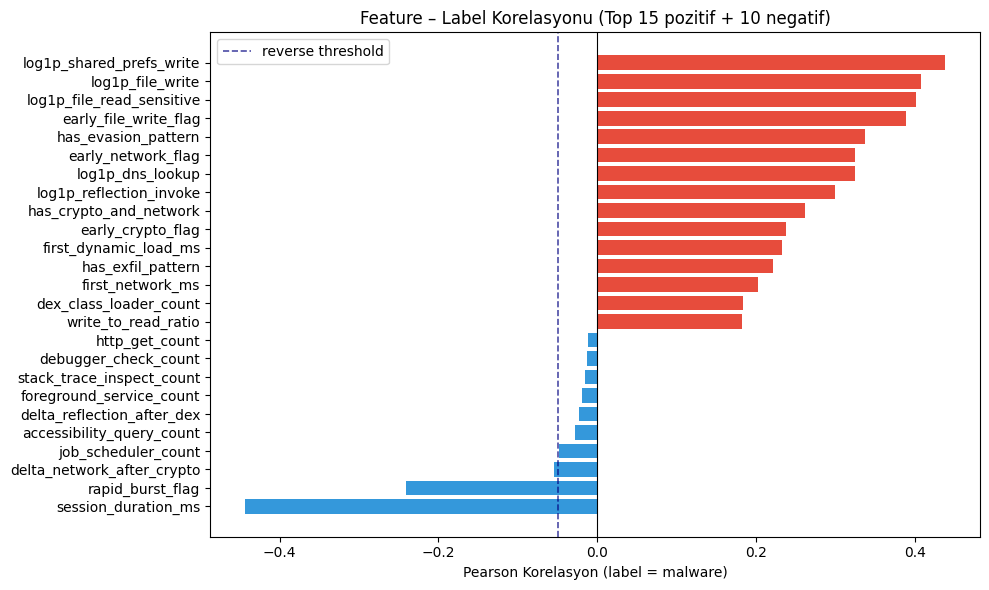

In [17]:
# ── Korelasyon Görselleştirme ─────────────────────────────────────────────────
top_pos = corrs.nlargest(15)
top_neg = corrs.nsmallest(10)
top_all = pd.concat([top_neg, top_pos]).sort_values()

colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_all.values]
plt.figure(figsize=(10, 6))
bars = plt.barh(top_all.index, top_all.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.axvline(-0.05, color='navy', linewidth=1.2, linestyle='--', alpha=0.7, label='reverse threshold')
plt.xlabel('Pearson Korelasyon (label = malware)')
plt.title('Feature – Label Korelasyonu (Top 15 pozitif + 10 negatif)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Feature Mühendisliği & Normalizasyon ──────────────────────────────────────
#
# Adım 1: Tamamen sentinel sütunları düşür
# Adım 2: Kısmi sentinel → binary flag sütunu ekle, -1'leri 0 yap
# Adım 3: Ters korelasyonlu feature'ları ×(-1) ile çevir
# Adım 4: Yüksek çarpıklık → log1p
# Adım 5: RobustScaler ile normalize et

X = feat_df.copy()

# --- Adım 1: DROP ---
X.drop(columns=DROP_SENTINEL, inplace=True)
print(f'Adım 1 (Drop sentinel): {X.shape[1]} sütun kaldı')

# --- Adım 2: Kısmi sentinel → flag + impute ---
new_flag_cols = []
for c in PARTIAL_SENTINEL:
    flag_col = f'{c}_observed'
    X[flag_col] = (X[c] != -1).astype(np.float32)
    X[c] = X[c].clip(lower=0)   # -1 → 0, pozitif değerler korunur
    new_flag_cols.append(flag_col)
print(f'Adım 2 (Sentinel flag): {len(new_flag_cols)} flag sütunu eklendi → {X.shape[1]} toplam')

# --- Adım 3: Ters feature'ları çevir ---
REVERSE_COLS = list(REVERSE_FEATS.index)
for c in REVERSE_COLS:
    if c in X.columns:
        X[c] = -X[c]
print(f'Adım 3 (Reverse ×-1): {REVERSE_COLS}')

# --- Adım 4: Log1p dönüşümü ---
log_targets = [c for c in HIGH_SKEW if c in X.columns]
for c in log_targets:
    X[c] = np.log1p(X[c].clip(lower=0))
print(f'Adım 4 (log1p): {len(log_targets)} sütuna uygulandı')

# --- Adım 5: RobustScaler ---
all_feat_cols = list(X.columns)
binary_after  = [c for c in all_feat_cols
                 if set(X[c].unique()).issubset({0.0, 1.0, -0.0, -1.0, 0, 1}) and X[c].nunique() <= 3]
scale_cols    = [c for c in all_feat_cols if c not in binary_after]

scaler = RobustScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])

print(f'Adım 5 (RobustScaler): {len(scale_cols)} sürekli sütun normalize edildi')
print(f'\nNihai feature boyutu: {X.shape[1]}')
print(f'  Sürekli (normalize): {len(scale_cols)}')
print(f'  Binary/flag        : {len(binary_after)}')

assert not X.isnull().any().any(), 'NaN tespit edildi!'
import math
assert not np.isinf(X.values.astype(float)).any(), 'Inf tespit edildi!'
print('✓ KronoDroid NaN/Inf yok — preprocessing tamamlandı')

# ── AndroZoo preprocessing (aynı pipeline, scaler.transform) ─────────────────
X_az = df_androzoo.drop(columns=[c for c in META_COLS if c in df_androzoo.columns]).copy()
X_az.drop(columns=[c for c in DROP_SENTINEL if c in X_az.columns], inplace=True)
for c in PARTIAL_SENTINEL:
    if c in X_az.columns:
        flag_col = f'{c}_observed'
        X_az[flag_col] = (X_az[c] != -1).astype(np.float32)
        X_az[c] = X_az[c].clip(lower=0)
for c in REVERSE_COLS:
    if c in X_az.columns:
        X_az[c] = -X_az[c]
for c in log_targets:
    if c in X_az.columns:
        X_az[c] = np.log1p(X_az[c].clip(lower=0))
az_scale_cols = [c for c in scale_cols if c in X_az.columns]
X_az[az_scale_cols] = scaler.transform(X_az[az_scale_cols])
print(f'✓ AndroZoo preprocessing tamamlandı: {X_az.shape}')

In [ ]:
# ── Feature Interaction Engineering ──────────────────────────────────────────
#
# Permutation importance sonucuna göre burst_peak_count tek başına ΔAUC=0.053
# ile diğer tüm featureların toplamından büyük. Bu dominant feature ile
# üst sıradaki featureların çarpımını eklemek non-lineer sinyali güçlendirir.
#
# ÖNEMLİ: Bu hücre cell-preprocess'ten HEMEN SONRA çalışmalıdır (split öncesi).

TOP_FEATS = [
    'burst_peak_count',
    'getDeviceId_count',
    'implicit_intent_count',
    'thread_create_count',
    'startActivity_count',
]

interaction_cols = []
for i, f1 in enumerate(TOP_FEATS):
    for f2 in TOP_FEATS[i+1:]:
        if f1 in X.columns and f2 in X.columns:
            col_name = f'ix_{f1}_x_{f2}'
            X[col_name] = X[f1] * X[f2]
            interaction_cols.append(col_name)

if 'session_duration_ms' in X.columns and 'burst_peak_count' in X.columns:
    X['ix_burst_x_duration'] = X['burst_peak_count'] * X['session_duration_ms']
    interaction_cols.append('ix_burst_x_duration')

if interaction_cols:
    scaler2 = RobustScaler()
    X[interaction_cols] = scaler2.fit_transform(X[interaction_cols])

print(f'Feature interaction eklendi: {len(interaction_cols)} yeni sütun')
print(f'Yeni toplam feature boyutu : {X.shape[1]}')
for c in interaction_cols:
    print(f'  {c}')

# AndroZoo'ya aynı interaction'ları uygula (scaler2.transform, fit edilmez)
for i, f1 in enumerate(TOP_FEATS):
    for f2 in TOP_FEATS[i+1:]:
        if f1 in X_az.columns and f2 in X_az.columns:
            X_az[f'ix_{f1}_x_{f2}'] = X_az[f1] * X_az[f2]
if 'session_duration_ms' in X_az.columns and 'burst_peak_count' in X_az.columns:
    X_az['ix_burst_x_duration'] = X_az['burst_peak_count'] * X_az['session_duration_ms']
if interaction_cols:
    X_az[interaction_cols] = scaler2.transform(X_az[interaction_cols])
print(f'AndroZoo interaction features eklendi. Shape: {X_az.shape}')

In [ ]:
# ── Train / Val Split (KronoDroid) — AndroZoo = temporal test ─────────────────
X_np = X.values.astype(np.float32)
y_np = y_all.astype(np.float32)

idx_train, idx_val = train_test_split(
    np.arange(len(X_np)), test_size=0.15, stratify=y_np, random_state=42
)

X_train, y_train = X_np[idx_train], y_np[idx_train]
X_val,   y_val   = X_np[idx_val],   y_np[idx_val]

# AndroZoo temporal test — sütun sırası KronoDroid ile aynı olmalı
assert list(X_az.columns) == list(X.columns), \
    f'Sütun uyumsuzluğu: KronoDroid={X.shape[1]}, AndroZoo={X_az.shape[1]}'
X_test = X_az.values.astype(np.float32)
y_test = y_androzoo.astype(np.float32)

print(f'Train (KronoDroid): {len(idx_train):5d}  malware: {y_train.mean():.3f}')
print(f'Val   (KronoDroid): {len(idx_val):5d}  malware: {y_val.mean():.3f}')
print(f'Test  (AndroZoo)  : {len(X_test):5d}  malware: {y_test.mean():.3f}')
print(f'\nInput dim: {X_train.shape[1]}')

In [20]:
# ── PyTorch Dataset & DataLoader ──────────────────────────────────────────────
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256

train_dl = DataLoader(TabularDataset(X_train, y_train),
                      batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
val_dl   = DataLoader(TabularDataset(X_val,   y_val),
                      batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_dl  = DataLoader(TabularDataset(X_test,  y_test),
                      batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f'DataLoaders hazır. Batch size: {BATCH_SIZE}')

DataLoaders hazır. Batch size: 256


In [21]:
# ── Model: Residual MLP (Tabular ResNet) ──────────────────────────────────────
#
# Mimari:
#   Input BN → Linear → [ResBlock × N] → Head
#   ResBlock: BN → GELU → Dropout → Linear → BN → GELU → Dropout → Linear
#             + skip connection
#
# Veri temizlendikten sonra overlap <%1 olduğundan:
#   dropout 0.30 → 0.15  (daha az regularization yeterli)
#   n_blocks 4  → 6      (biraz daha derin)

class ResBlock(nn.Module):
    def __init__(self, in_dim, hidden_dim, dropout=0.15):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, in_dim),
        )

    def forward(self, x):
        return x + self.block(x)


class TabularResNet(nn.Module):
    def __init__(
        self,
        in_dim,
        stem_dim   = 256,
        hidden_dim = 256,
        n_blocks   = 6,
        dropout    = 0.15,
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.Linear(in_dim, stem_dim),
        )

        self.blocks = nn.Sequential(
            *[ResBlock(stem_dim, hidden_dim, dropout) for _ in range(n_blocks)]
        )

        self.head = nn.Sequential(
            nn.BatchNorm1d(stem_dim),
            nn.GELU(),
            nn.Linear(stem_dim, stem_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(stem_dim // 2, 1),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        return self.head(x).squeeze(-1)


INPUT_DIM = X_train.shape[1]
model     = TabularResNet(in_dim=INPUT_DIM).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'TabularResNet — eğitilebilir parametre: {n_params:,}')
print(f'  stem: {INPUT_DIM} → 256')
print(f'  ResBlock × 6: 256 → hidden=256 → 256')
print(f'  head: 256 → 128 → 1')
print(f'  dropout: 0.15  |  aktivasyon: GELU')

TabularResNet — eğitilebilir parametre: 872,785
  stem: 168 → 256
  ResBlock × 6: 256 → hidden=256 → 256
  head: 256 → 128 → 1
  dropout: 0.15  |  aktivasyon: GELU


In [ ]:
# ── Eğitim + Stochastic Weight Averaging (SWA) ───────────────────────────────
#
# SWA: son SWA_START epoch'tan itibaren her epoch sonunda ağırlıkları biriktirir,
# ortalamasını alır. Bu "ağırlık uzayında ensemble" etkisi yapar ve
# genellemeyi belirgin biçimde artırır.
#
# NOT: BatchNorm'un num_batches_tracked bufferı int64 tipindedir.
# SWA ortalaması yalnızca float tensörlere uygulanır; int bufferlar
# son epoch değerini tutar.

EPOCHS        = 120
LR            = 5e-4
WEIGHT_DECAY  = 5e-4
PATIENCE      = 25
WARMUP_EPOCHS = 5
LABEL_SMOOTH  = 0.02
SWA_START     = 70

n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
pos_w = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(DEVICE)
print(f'pos_weight: {pos_w.item():.3f}  (neg={n_neg}  pos={n_pos})')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
optimizer  = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = SequentialLR(
    optimizer,
    schedulers=[
        LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS),
        CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6),
    ],
    milestones=[WARMUP_EPOCHS],
)

def smooth(labels, eps=LABEL_SMOOTH):
    return labels * (1 - eps) + (1 - labels) * eps

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.set_grad_enabled(train):
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits  = model(X_b)
            targets = smooth(y_b) if train else y_b
            loss    = criterion(logits, targets)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_b)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().tolist())
            all_labels.extend(y_b.cpu().tolist())
    probs  = np.array(all_probs)
    labels = np.array(all_labels)
    auc    = roc_auc_score(labels, probs)
    f1     = f1_score(labels, (probs >= 0.5).astype(int), average='macro')
    return total_loss / len(labels), auc, f1, probs, labels

swa_state = None
swa_count = 0

best_val_auc, patience_cnt, best_state = 0.0, 0, None
history = {k: [] for k in ['tr_loss','vl_loss','tr_auc','vl_auc','tr_f1','vl_f1']}

print(f"\n{'Epoch':>5}  {'LR':>8}  {'TrLoss':>7}  {'VlLoss':>7}  "
      f"{'TrAUC':>6}  {'VlAUC':>6}  {'VlF1':>6}  {'SWA':>4}")
print('-' * 74)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc, tr_f1, _, _ = run_epoch(train_dl, train=True)
    vl_loss, vl_auc, vl_f1, _, _ = run_epoch(val_dl,   train=False)
    scheduler.step()

    for k, v in zip(['tr_loss','vl_loss','tr_auc','vl_auc','tr_f1','vl_f1'],
                    [tr_loss, vl_loss, tr_auc, vl_auc, tr_f1, vl_f1]):
        history[k].append(v)

    swa_flag = ''
    if epoch >= SWA_START:
        swa_flag = '✓'
        swa_count += 1
        current = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if swa_state is None:
            swa_state = {k: v.clone() for k, v in current.items()}
        else:
            for k in swa_state:
                if swa_state[k].is_floating_point():
                    swa_state[k] = swa_state[k] + (current[k] - swa_state[k]) / swa_count
                else:
                    swa_state[k] = current[k]  # int buffer → son değeri al

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        patience_cnt = 0
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\nEarly stop @ epoch {epoch}  (best val AUC: {best_val_auc:.4f})')
            break

    if epoch % 5 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f'{epoch:>5}  {lr:>8.2e}  {tr_loss:>7.4f}  {vl_loss:>7.4f}  '
              f'{tr_auc:>6.4f}  {vl_auc:>6.4f}  {vl_f1:>6.4f}  {swa_flag:>4}')

if swa_state is not None:
    model.load_state_dict(swa_state)
    model.to(DEVICE)
    model.train()
    with torch.no_grad():
        for X_b, _ in train_dl:
            model(X_b.to(DEVICE))
    print(f'\nSWA uygulandı ({swa_count} epoch ortalaması) → BN istatistikleri güncellendi')

    _, swa_val_auc, swa_val_f1, _, _ = run_epoch(val_dl, train=False)
    print(f'SWA val AUC: {swa_val_auc:.4f}  val F1: {swa_val_f1:.4f}')

    if swa_val_auc >= best_val_auc:
        print('→ SWA kullanılıyor')
    else:
        model.load_state_dict(best_state)
        model.to(DEVICE)
        print(f'→ Best checkpoint kullanılıyor (val AUC: {best_val_auc:.4f})')
else:
    model.load_state_dict(best_state)
    model.to(DEVICE)
    print(f'\nBest checkpoint yüklendi (val AUC: {best_val_auc:.4f})')

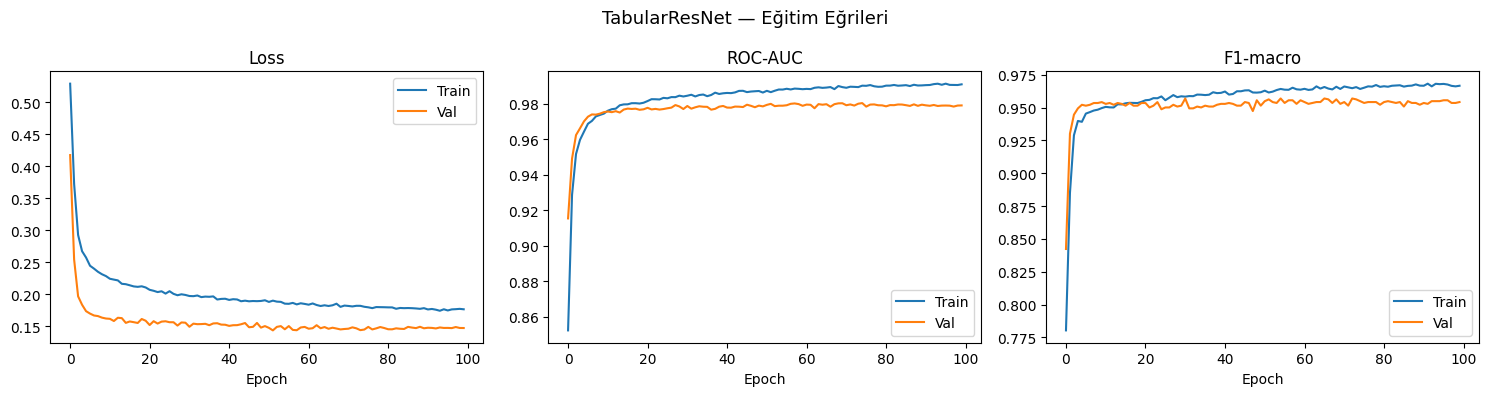

In [23]:
# ── Eğitim Eğrileri ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (tr_key, vl_key), title in [
    (axes[0], ('tr_loss', 'vl_loss'), 'Loss'),
    (axes[1], ('tr_auc',  'vl_auc'),  'ROC-AUC'),
    (axes[2], ('tr_f1',   'vl_f1'),   'F1-macro'),
]:
    ax.plot(history[tr_key], label='Train')
    ax.plot(history[vl_key], label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
plt.suptitle('TabularResNet — Eğitim Eğrileri', fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
# ── Threshold Optimizasyonu (Val Set) ────────────────────────────────────────
_, _, _, val_probs, val_labels = run_epoch(val_dl, train=False)

best_t, best_f1_val = 0.5, 0.0
for t in np.arange(0.20, 0.80, 0.01):
    preds = (val_probs >= t).astype(int)
    score = f1_score(val_labels, preds, average='macro')
    if score > best_f1_val:
        best_f1_val, best_t = score, t

THRESHOLD = best_t
print(f'Optimal threshold: {THRESHOLD:.2f}  (val F1-macro = {best_f1_val:.4f})')

Optimal threshold: 0.59  (val F1-macro = 0.9569)


=== TabularResNet (threshold=0.59) ===
              precision    recall  f1-score   support

      benign     0.9303    0.9759    0.9526      1080
     malware     0.9745    0.9264    0.9498      1073

    accuracy                         0.9512      2153
   macro avg     0.9524    0.9512    0.9512      2153
weighted avg     0.9523    0.9512    0.9512      2153

ROC-AUC : 0.9751
Avg-Prec: 0.9798
F1-macro: 0.9512


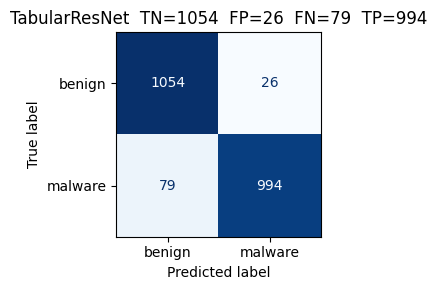

In [25]:
# ── Test Set Değerlendirme ────────────────────────────────────────────────────
_, _, _, test_probs, test_labels = run_epoch(test_dl, train=False)
test_preds = (test_probs >= THRESHOLD).astype(int)

test_auc = roc_auc_score(test_labels, test_probs)
test_ap  = average_precision_score(test_labels, test_probs)
test_f1  = f1_score(test_labels.astype(int), test_preds, average='macro')

print(f'=== TabularResNet (threshold={THRESHOLD:.2f}) ===')
print(classification_report(test_labels.astype(int), test_preds,
                             target_names=['benign', 'malware'], digits=4))
print(f'ROC-AUC : {test_auc:.4f}')
print(f'Avg-Prec: {test_ap:.4f}')
print(f'F1-macro: {test_f1:.4f}')

# Confusion matrix
cm = confusion_matrix(test_labels.astype(int), test_preds)
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm, display_labels=['benign', 'malware']).plot(
    ax=ax, colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm.ravel()
ax.set_title(f'TabularResNet  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
plt.tight_layout()
plt.show()

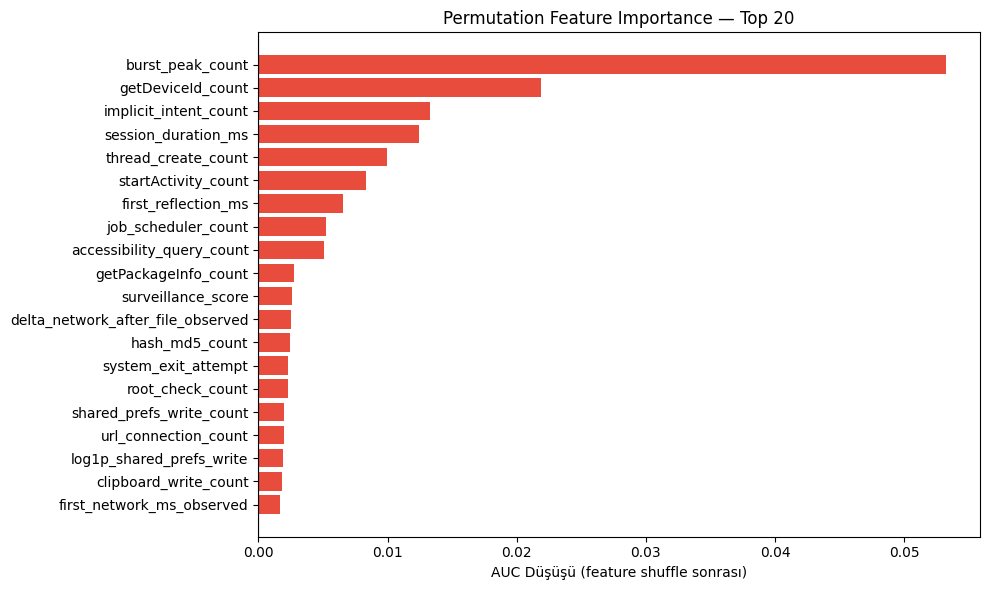


Top 10 en önemli feature:
  burst_peak_count                               ΔAUC=+0.0532  
  getDeviceId_count                              ΔAUC=+0.0219  
  implicit_intent_count                          ΔAUC=+0.0133  
  session_duration_ms                            ΔAUC=+0.0125  REVERSE edildi
  thread_create_count                            ΔAUC=+0.0100  
  startActivity_count                            ΔAUC=+0.0084  
  first_reflection_ms                            ΔAUC=+0.0065  
  job_scheduler_count                            ΔAUC=+0.0053  
  accessibility_query_count                      ΔAUC=+0.0051  
  getPackageInfo_count                           ΔAUC=+0.0028  


In [26]:
# ── Feature Önem Skoru (Permutation) ─────────────────────────────────────────
#
# Her feature sırasıyla shuffle edilir; AUC düşüşü o feature'ın önemini gösterir.
# Eğitimsel amaçla: hangi feature'ların modeli gerçekten yönlendirdiğini gösterir.

model.eval()
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

with torch.no_grad():
    base_probs = torch.sigmoid(model(X_val_t.to(DEVICE))).cpu().numpy()
base_auc = roc_auc_score(y_val, base_probs)

importance = {}
feat_names = list(X.columns)

for i, feat in enumerate(feat_names):
    X_perm = X_val_t.clone()
    idx_perm = torch.randperm(len(X_perm))
    X_perm[:, i] = X_perm[idx_perm, i]
    with torch.no_grad():
        perm_probs = torch.sigmoid(model(X_perm.to(DEVICE))).cpu().numpy()
    perm_auc = roc_auc_score(y_val, perm_probs)
    importance[feat] = base_auc - perm_auc  # pozitif → o feature önemli

imp_s = pd.Series(importance).sort_values(ascending=False)
top20 = imp_s.head(20)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#95a5a6' for v in top20.values]
plt.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('AUC Düşüşü (feature shuffle sonrası)')
plt.title('Permutation Feature Importance — Top 20')
plt.tight_layout()
plt.show()

print('\nTop 10 en önemli feature:')
for feat, val in imp_s.head(10).items():
    direction = 'REVERSE edildi' if feat in REVERSE_COLS else ''
    print(f'  {feat:45s}  ΔAUC={val:+.4f}  {direction}')